In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

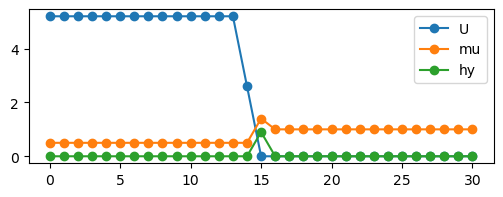

In [20]:
widthS = 15
widthF1 = 1
widthF2 = 15
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.1

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2

V = None

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [25]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F0_init=0.1, hx=hy)

In [26]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=100, verbose=True, temperature=T)

F0:
Absolute error: 1.2326199460227256
Relative error: 55499651228.322876
Average old: (0.04838709677419355+0j)
Average: (0.20450536659218524+0j)
F_xplus:
Absolute error: 0.10558268475435718
Relative error: 105582684754.3572
Average old: 0j
Average: (-0.013631943630835955+0j)
F_xmin:
Absolute error: 0.10558268475435693
Relative error: 105582684754.35693
Average old: 0j
Average: (-0.013631943630835927+0j)
F_yplus:
Absolute error: 0.12184950605925916
Relative error: 121849506059.25916
Average old: 0j
Average: (-0.015491053161372382+9.038185514247826e-17j)
F_ymin:
Absolute error: 0.12184950605925916
Relative error: 121849506059.25916
Average old: 0j
Average: (-0.015491053161372382-9.038185514247826e-17j)
Fuu_xplus:
Absolute error: 0.040476474006404646
Relative error: 40476474006.40464
Average old: 0j
Average: (0.0036053263161175634+0j)
Fuu_xmin:
Absolute error: 0.040476474006404084
Relative error: 40476474006.40408
Average old: 0j
Average: (-0.003605326316117452+0j)
Fuu_yplus:
Absolute er

In [27]:
F, Fuu, Fdd = H.get_correlations()


T/t=0.1, hz/t=0.9


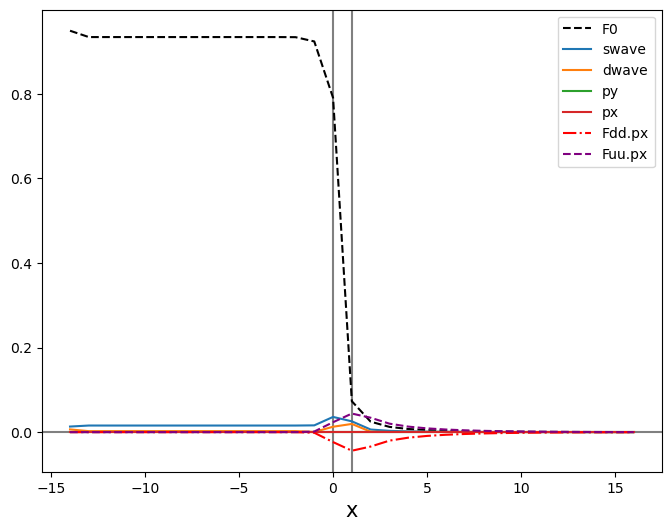

In [29]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"T/t={T}, hz/t={h0}")
print(f"T/t={T}, hz/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.real(H.F0), label=r"F0", color='black', linestyle='--')
axs.plot(x, np.abs(F.swave), label=r"swave",)
axs.plot(x, np.abs(F.dwave), label=r"dwave")
axs.plot(x, np.abs(F.py), label=r"py")
axs.plot(x, np.abs(F.px), label=r"px")
axs.plot(x, np.real(Fdd.px), "-.", label=r"Fdd.px", color='red')
# axs.plot(x, np.imag(Fdd.px), "--", label=r"Fdd", color='green')
axs.plot(x, np.real(Fuu.px), "--", label=r"Fuu.px", color='purple')

axs.set_xlabel("x", fontsize=15)
plt.legend()
plt.show()